# Tokenizer Evaluation — SentencePiece Unigram vs. Byte-Level BPE

Compares the two 20,000-vocab tokenizers trained in `scripts/train_sentencepiece.py` and `scripts/train_bpe.py`, on the held-out set built by `scripts/build_training_corpus.py` (the 2,000 docs cached in `Data/sample_*.jsonl`, excluded from training). This compares the *algorithm* choice at a matched vocab budget — no vocab-size sweep, no downstream/perplexity evaluation (see `PLAN.md`).

## 1. Setup

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import sentencepiece as spm
from tokenizers import Tokenizer as HFTokenizer

# Same Arabic-rendering fix as Notebooks/03_build_vocabulary.ipynb: matplotlib's
# default font has no Arabic glyphs, and doesn't apply Arabic shaping/bidi itself.
plt.rcParams["font.family"] = ["Segoe UI", "Tahoma", "Arial", "DejaVu Sans"]
try:
    import arabic_reshaper
    from bidi.algorithm import get_display

    def display_ar(text):
        return get_display(arabic_reshaper.reshape(text))
except ImportError:
    def display_ar(text):
        return text

ROOT = Path.cwd()  # Tokenization/
DARIJA_ROOT = ROOT.parent

sp = spm.SentencePieceProcessor(model_file=str(ROOT / "models" / "sentencepiece" / "darija_unigram.model"))
bpe = HFTokenizer.from_file(str(ROOT / "models" / "bpe" / "tokenizer.json"))

print(f"SentencePiece vocab size: {sp.vocab_size():,}")
print(f"BPE vocab size: {bpe.get_vocab_size():,}")

heldout_path = ROOT / "data" / "heldout_docs.jsonl"
with heldout_path.open("r", encoding="utf-8") as f:
    heldout_docs = [json.loads(line) for line in f if line.strip()]
print(f"held-out docs: {len(heldout_docs):,}")


def sp_pieces(text):
    return sp.encode(text, out_type=str)


def bpe_pieces(text):
    return bpe.encode(text).tokens


TOKENIZERS = {"SentencePiece Unigram": sp_pieces, "Byte-level BPE": bpe_pieces}

SentencePiece vocab size: 20,000
BPE vocab size: 20,000
held-out docs: 1,926


### Script classifier (reused from `03_build_vocabulary.ipynb`)

In [2]:
_ARABIC_RE = re.compile(r"[؀-ۿ]")
_LATIN_RE = re.compile(r"[a-zA-Z]")


def classify_script(word):
    has_ar = bool(_ARABIC_RE.search(word))
    has_lat = bool(_LATIN_RE.search(word))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


WORDS = [(w, classify_script(w)) for doc in heldout_docs for w in doc["text"].split() if w.strip()]
print(f"held-out whitespace-words: {len(WORDS):,}")
print(Counter(script for _, script in WORDS))

held-out whitespace-words: 117,306
Counter({'arabic': 109452, 'other': 6167, 'latin': 1668, 'mixed': 19})


## 2. Fertility (tokens per whitespace-word)

Split by script so a tokenizer that's much worse on one script can't hide behind a good aggregate number.

            tokenizer script  words  tokens  fertility
SentencePiece Unigram arabic 109452  157120   1.435515
SentencePiece Unigram  other   6167    8251   1.337928
SentencePiece Unigram  latin   1668    3903   2.339928
SentencePiece Unigram  mixed     19     101   5.315789
SentencePiece Unigram    ALL 117306  169375   1.443873
       Byte-level BPE arabic 109452  197957   1.808619
       Byte-level BPE  other   6167    8461   1.371980
       Byte-level BPE  latin   1668    4456   2.671463
       Byte-level BPE  mixed     19     108   5.684211
       Byte-level BPE    ALL 117306  210982   1.798561


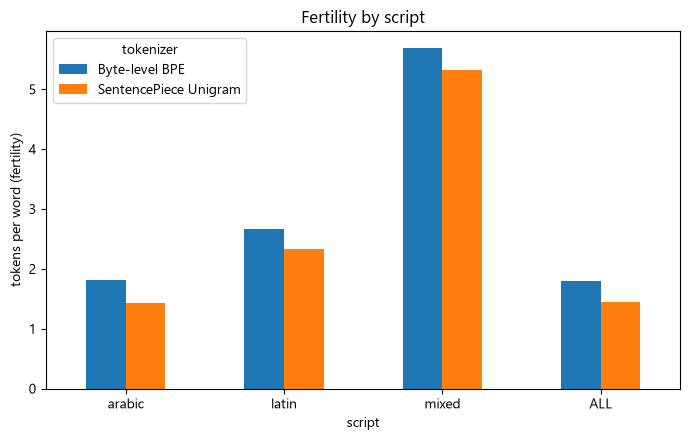

In [3]:
fertility_rows = []
for tok_name, tokenize_fn in TOKENIZERS.items():
    per_script_tokens = Counter()
    per_script_words = Counter()
    for word, script in WORDS:
        n_pieces = len(tokenize_fn(word))
        per_script_tokens[script] += n_pieces
        per_script_words[script] += 1
    for script in per_script_words:
        fertility_rows.append({
            "tokenizer": tok_name,
            "script": script,
            "words": per_script_words[script],
            "tokens": per_script_tokens[script],
            "fertility": per_script_tokens[script] / per_script_words[script],
        })
    overall_tokens = sum(per_script_tokens.values())
    overall_words = sum(per_script_words.values())
    fertility_rows.append({
        "tokenizer": tok_name,
        "script": "ALL",
        "words": overall_words,
        "tokens": overall_tokens,
        "fertility": overall_tokens / overall_words,
    })

fertility_df = pd.DataFrame(fertility_rows)
print(fertility_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot = fertility_df[fertility_df["script"] != "other"].pivot(index="script", columns="tokenizer", values="fertility")
pivot = pivot.reindex(["arabic", "latin", "mixed", "ALL"])
pivot.plot.bar(ax=ax)
ax.set_ylabel("tokens per word (fertility)")
ax.set_title("Fertility by script")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Compression ratio

The metric that matters most given the project's short (64-96 token) context-length design (`Project_context.md`'s hardware note) — higher compression means more real content fits in that window.

            tokenizer  chars_per_token  bytes_per_token  total_tokens
SentencePiece Unigram         3.359168         5.948572        181478
       Byte-level BPE         3.438674         6.089366        177282


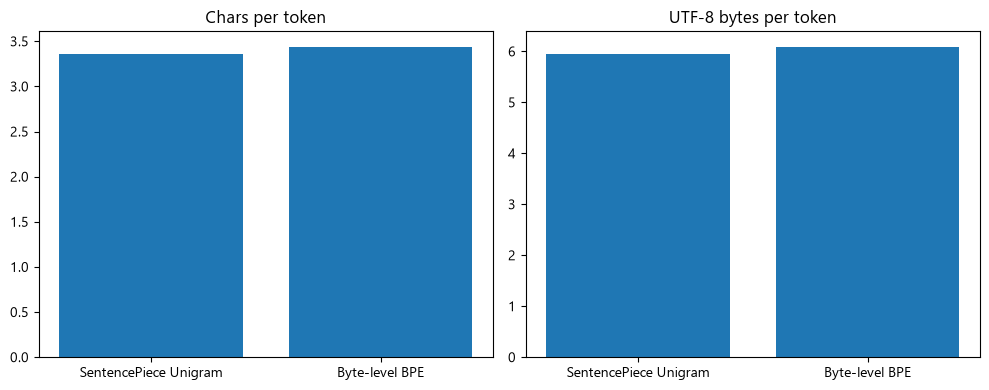

In [4]:
compression_rows = []
for tok_name, tokenize_fn in TOKENIZERS.items():
    total_chars = 0
    total_bytes = 0
    total_tokens = 0
    for doc in heldout_docs:
        text = doc["text"]
        total_chars += len(text)
        total_bytes += len(text.encode("utf-8"))
        total_tokens += len(tokenize_fn(text))
    compression_rows.append({
        "tokenizer": tok_name,
        "chars_per_token": total_chars / total_tokens,
        "bytes_per_token": total_bytes / total_tokens,
        "total_tokens": total_tokens,
    })

compression_df = pd.DataFrame(compression_rows)
print(compression_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(compression_df["tokenizer"], compression_df["chars_per_token"])
axes[0].set_title("Chars per token")
axes[1].bar(compression_df["tokenizer"], compression_df["bytes_per_token"])
axes[1].set_title("UTF-8 bytes per token")
plt.tight_layout()
plt.show()

## 4. Vocabulary utilization

What fraction of the trained vocab actually shows up at non-trivial frequency on held-out text — a large "dead" tail means the vocab size is bigger than the (held-out) data supports.

            tokenizer  vocab_size  distinct_pieces_used  utilization_pct
SentencePiece Unigram       20000                 14152           70.760
       Byte-level BPE       20000                 15207           76.035


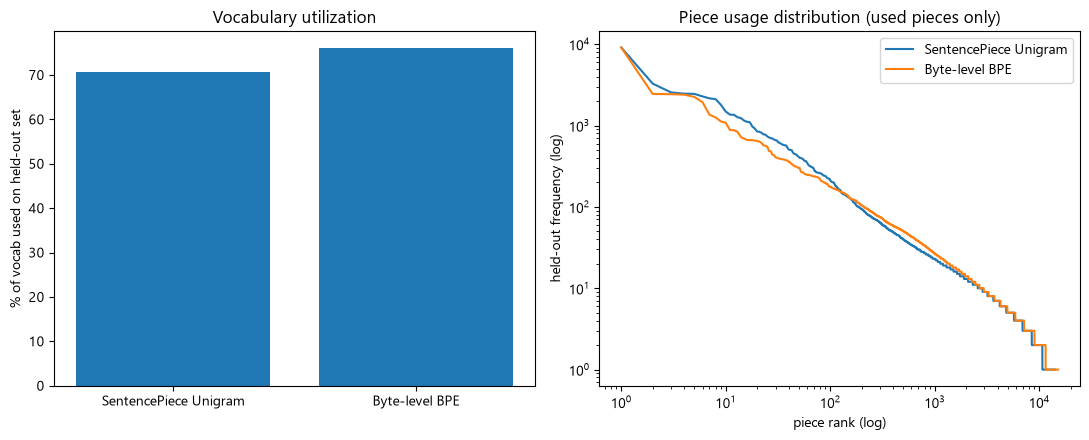

In [5]:
utilization_rows = []
piece_freqs = {}
for tok_name, tokenize_fn in TOKENIZERS.items():
    freqs = Counter()
    for doc in heldout_docs:
        freqs.update(tokenize_fn(doc["text"]))
    piece_freqs[tok_name] = freqs
    vocab_size = sp.vocab_size() if tok_name == "SentencePiece Unigram" else bpe.get_vocab_size()
    utilization_rows.append({
        "tokenizer": tok_name,
        "vocab_size": vocab_size,
        "distinct_pieces_used": len(freqs),
        "utilization_pct": len(freqs) / vocab_size * 100,
    })

utilization_df = pd.DataFrame(utilization_rows)
print(utilization_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(utilization_df["tokenizer"], utilization_df["utilization_pct"])
axes[0].set_ylabel("% of vocab used on held-out set")
axes[0].set_title("Vocabulary utilization")

for tok_name, freqs in piece_freqs.items():
    counts_sorted = sorted(freqs.values(), reverse=True)
    axes[1].plot(range(1, len(counts_sorted) + 1), counts_sorted, label=tok_name)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("piece rank (log)")
axes[1].set_ylabel("held-out frequency (log)")
axes[1].set_title("Piece usage distribution (used pieces only)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. OOV / byte-fallback rate

For SentencePiece, byte-fallback pieces render as `<0xXX>` -- how often that actually fires. For byte-level BPE this is expected to be ~0 by construction (every byte is in the base vocab via `ByteLevel.alphabet()`) -- noted as an expected asymmetry between the two algorithms, not scored against BPE.

In [6]:
BYTE_FALLBACK_RE = re.compile(r"^<0x[0-9A-Fa-f]{2}>$")

sp_pieces_all = piece_freqs["SentencePiece Unigram"]
sp_total_pieces = sum(sp_pieces_all.values())
sp_fallback_pieces = sum(c for p, c in sp_pieces_all.items() if BYTE_FALLBACK_RE.match(p))
print(f"SentencePiece: {sp_fallback_pieces:,}/{sp_total_pieces:,} pieces were byte-fallback "
      f"({sp_fallback_pieces / sp_total_pieces * 100:.3f}%)")

bpe_unk_count = sum(1 for doc in heldout_docs for t in bpe.encode(doc["text"]).tokens if t == "<unk>")
bpe_total = sum(piece_freqs["Byte-level BPE"].values())
print(f"Byte-level BPE: {bpe_unk_count:,}/{bpe_total:,} tokens were <unk> "
      f"({bpe_unk_count / bpe_total * 100:.3f}%) -- expected ~0, byte-level has no true OOV")

SentencePiece: 9,360/181,478 pieces were byte-fallback (5.158%)
Byte-level BPE: 0/177,282 tokens were <unk> (0.000%) -- expected ~0, byte-level has no true OOV


## 6. Known-word integrity

Do the 9 validated Darija function words (`Project_context.md`) and the top ~100 rows of `Data/vocab_unigrams.csv` come out as a single token, or get fragmented? A high-frequency word splitting into several pieces is a real signal about vocab fit, not expected noise.

In [7]:
KNOWN_DARIJA_WORDS = ["wach", "kayen", "bezzaf", "raki", "chkoun", "khoya", "wallah", "hna", "kima"]

vocab_df = pd.read_csv(DARIJA_ROOT / "Data" / "vocab_unigrams.csv")
top100_words = vocab_df.head(100)["token"].tolist()

check_words = list(dict.fromkeys(KNOWN_DARIJA_WORDS + top100_words))  # dedupe, preserve order

fragmentation_rows = []
for tok_name, tokenize_fn in TOKENIZERS.items():
    fragmented = 0
    for w in check_words:
        n_pieces = len(tokenize_fn(w))
        if n_pieces > 1:
            fragmented += 1
    fragmentation_rows.append({
        "tokenizer": tok_name,
        "words_checked": len(check_words),
        "fragmented": fragmented,
        "fragmented_pct": fragmented / len(check_words) * 100,
    })
print(pd.DataFrame(fragmentation_rows).to_string(index=False))

print("\n--- the 9 known Darija words specifically ---")
for w in KNOWN_DARIJA_WORDS:
    parts = {tok_name: fn(w) for tok_name, fn in TOKENIZERS.items()}
    print(f"{w!r}: " + " | ".join(f"{name}={pieces}" for name, pieces in parts.items()))

            tokenizer  words_checked  fragmented  fragmented_pct
SentencePiece Unigram            109           0        0.000000
       Byte-level BPE            109          14       12.844037

--- the 9 known Darija words specifically ---
'wach': SentencePiece Unigram=['▁wach'] | Byte-level BPE=['wa', 'ch']
'kayen': SentencePiece Unigram=['▁kayen'] | Byte-level BPE=['kay', 'en']
'bezzaf': SentencePiece Unigram=['▁bezzaf'] | Byte-level BPE=['be', 'z', 'zaf']
'raki': SentencePiece Unigram=['▁raki'] | Byte-level BPE=['ra', 'ki']
'chkoun': SentencePiece Unigram=['▁chkoun'] | Byte-level BPE=['ch', 'koun']
'khoya': SentencePiece Unigram=['▁khoya'] | Byte-level BPE=['kho', 'ya']
'wallah': SentencePiece Unigram=['▁wallah'] | Byte-level BPE=['wal', 'lah']
'hna': SentencePiece Unigram=['▁hna'] | Byte-level BPE=['h', 'na']
'kima': SentencePiece Unigram=['▁kima'] | Byte-level BPE=['ki', 'ma']


## 7. Round-trip fidelity

`decode(encode(text)) == text` should hold for the whole held-out set for both tokenizers (lossless by construction: byte-fallback / byte-level BPE) -- confirmed empirically rather than assumed, consistent with this project's validation discipline all session.

In [8]:
sp_mismatches = []
bpe_mismatches = []
for doc in heldout_docs:
    text = doc["text"]
    sp_decoded = sp.decode(sp.encode(text, out_type=int))
    if sp_decoded != text:
        sp_mismatches.append((text, sp_decoded))
    bpe_decoded = bpe.decode(bpe.encode(text).ids)
    if bpe_decoded != text:
        bpe_mismatches.append((text, bpe_decoded))

print(f"SentencePiece round-trip mismatches: {len(sp_mismatches)}/{len(heldout_docs)}")
print(f"Byte-level BPE round-trip mismatches: {len(bpe_mismatches)}/{len(heldout_docs)}")

for label, mismatches in [("SentencePiece", sp_mismatches), ("BPE", bpe_mismatches)]:
    for original, decoded in mismatches[:3]:
        print(f"\n[{label}] MISMATCH")
        print("  original:", repr(original[:150]))
        print("  decoded: ", repr(decoded[:150]))

SentencePiece round-trip mismatches: 0/1926
Byte-level BPE round-trip mismatches: 0/1926


## 8. Segmentation visualizations

Each example rendered as a horizontal sequence of colored boxes, one per token, color cycling through a fixed palette so adjacent tokens are visually distinct. Both tokenizers' segmentation of the *same* example shown stacked for direct comparison.

**Known simplification**: boxes are laid out in left-to-right token-sequence order regardless of script directionality -- a full bidi-aware paragraph layout is real extra complexity for a visualization tool, and this is the same simplification common tokenizer-visualization tools make for RTL text.

BPE token strings are raw byte-mapped representations internally (not literal Arabic) -- each token is individually re-decoded via the tokenizer for a human-readable label; on the rare token that represents only part of a multi-byte UTF-8 character, that decode can come back empty, so it falls back to the raw piece string (which itself is informative: it shows BPE fragmenting a character's bytes across token boundaries).

In [9]:
PALETTE = ["#a6cee3", "#b2df8a", "#fdbf6f", "#fb9a99", "#cab2d6", "#ffff99", "#8dd3c7", "#fccde5"]


def sp_segments(text):
    return [display_ar(p.replace("\u2581", " ")).strip() or "·" for p in sp.encode(text, out_type=str)]


def bpe_segments(text):
    enc = bpe.encode(text)
    segments = []
    for id_, raw_piece in zip(enc.ids, enc.tokens):
        decoded = bpe.decode([id_])
        label = decoded if decoded.strip() else raw_piece
        segments.append(display_ar(label.strip()) or "·")
    return segments


def plot_segments(ax, segments, title):
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlim(0, max(len(segments), 1))
    ax.set_ylim(0, 1)
    ax.axis("off")
    for i, seg in enumerate(segments):
        color = PALETTE[i % len(PALETTE)]
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor="white"))
        ax.text(i + 0.5, 0.5, seg, ha="center", va="center", fontsize=11)


def compare_segmentation(text, label):
    fig, axes = plt.subplots(2, 1, figsize=(max(6, 0.9 * max(
        len(sp_segments(text)), len(bpe_segments(text)))), 2.6))
    plot_segments(axes[0], sp_segments(text), f"{label} — SentencePiece Unigram")
    plot_segments(axes[1], bpe_segments(text), f"{label} — Byte-level BPE")
    plt.tight_layout()
    plt.show()

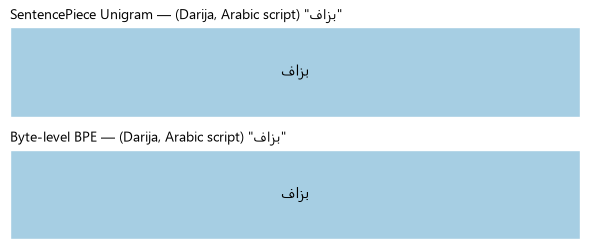

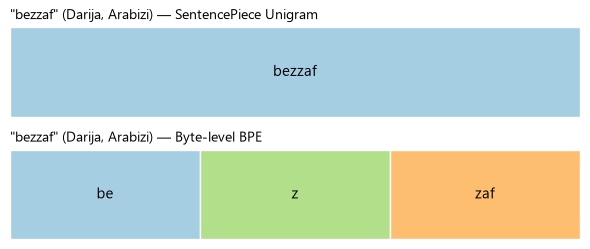

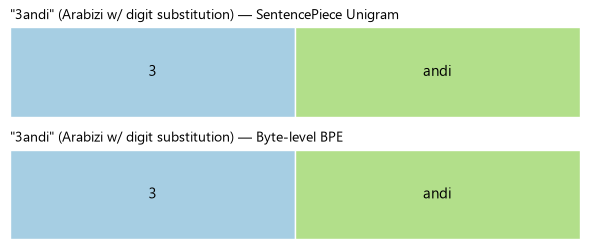

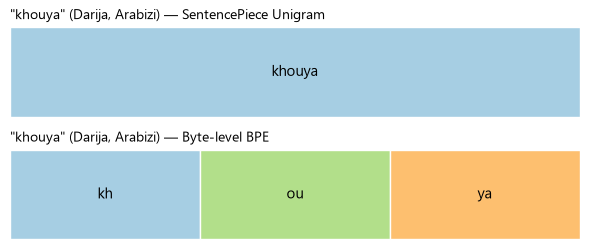

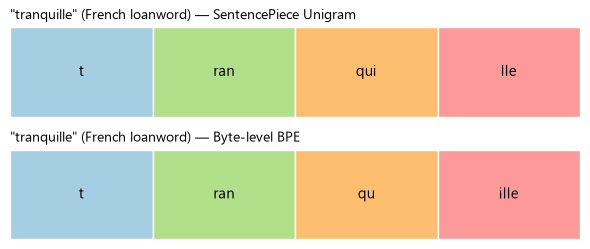

In [10]:
example_words = [
    ("بزاف", "Darija, Arabic script"),
    ("bezzaf", "Darija, Arabizi"),
    ("3andi", "Arabizi w/ digit substitution"),
    ("khouya", "Darija, Arabizi"),
    ("tranquille", "French loanword"),
]
for word, label in example_words:
    compare_segmentation(word, f'"{word}" ({label})')

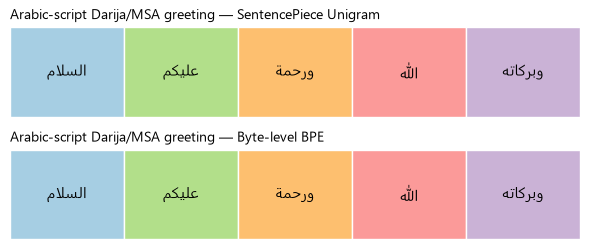

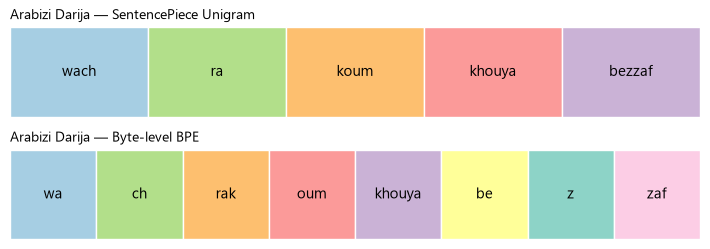

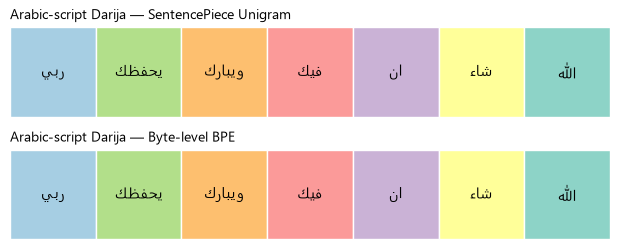

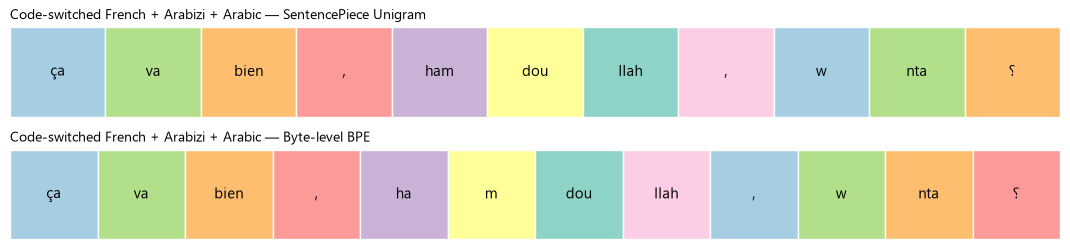

C:\Users\ASUS\AppData\Local\Temp\ipykernel_40148\1809066474.py:34: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Tahoma, Arial, DejaVu Sans, Segoe UI.
  plt.tight_layout()
c:\Users\ASUS\Desktop\summer 2026\deep learning\labs\training neural networks\ai-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Tahoma, Arial, DejaVu Sans, Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


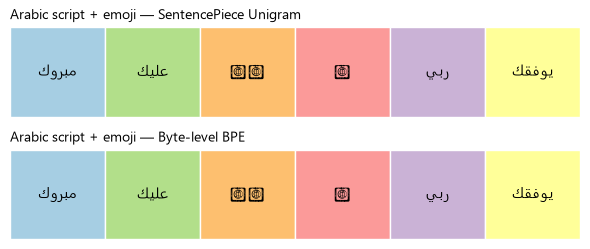

In [11]:
example_sentences = [
    ("السلام عليكم ورحمة الله وبركاته", "Arabic-script Darija/MSA greeting"),
    ("wach rakoum khouya bezzaf", "Arabizi Darija"),
    ("ربي يحفظك ويبارك فيك ان شاء الله", "Arabic-script Darija"),
    ("ça va bien, hamdoullah, w nta؟", "Code-switched French + Arabizi + Arabic"),
    ("مبروك عليك 🎉🎉🎉 ربي يوفقك", "Arabic script + emoji"),
]
for sentence, label in example_sentences:
    compare_segmentation(sentence, label)